# Import

In [ ]:
# Import library untuk analisis data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Untuk machine learning dan preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Untuk menampilkan semua kolom
pd.set_option('display.max_columns', None)

import semua library

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parasharmanas/movie-recommendation-system")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/movie-recommendation-system


download dataset melalui path kaggle

# Load Data

In [ ]:
print(os.listdir(path))

['movies.csv', 'ratings.csv']


melihat list dataset

In [ ]:
movies = pd.read_csv(os.path.join(path, 'movies.csv'))
ratings = pd.read_csv(os.path.join(path, 'ratings.csv'))

menginisiasi dataset mejadi variabel

In [ ]:
print('Total film yang tersedia:', len(movies.movieId.unique()))
print('Total pengguna yang memberikan rating:', len(ratings.userId.unique()))

Total film yang tersedia: 62423
Total pengguna yang memberikan rating: 162541


melihat total bedasarkan userID

# Data Understanding

In [ ]:
# informasi dataset movies
movies.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


melihat info dari movies, terdapat 3 kolom dengan total 62423 row

In [ ]:
# informasi dataset ratings
ratings.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


melihat info dari ratings, terdapat 4 kolom dengan total 25000095 row

In [ ]:
print('\nMissing values in movies dataset:')
print(movies.isnull().sum())

print('\nMissing values in ratings dataset:')
print(ratings.isnull().sum())


Missing values in movies dataset:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings dataset:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


melihat nilai null dari movies dan ratings, tidak ada nilai null pada kedua dataset

In [ ]:
# dataset movies
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
62418,209157,We (2018),Drama
62419,209159,Window of the Soul (2001),Documentary
62420,209163,Bad Poems (2018),Comedy|Drama
62421,209169,A Girl Thing (2001),(no genres listed)


melihat dataset movies

In [ ]:
movies['year_of_release'] = movies.title.str.extract('([0-9]{4})')
movies.head()

,movieId,title,genres,year_of_release
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


Mengekstrak tahun rilis dari kolom title dan menyimpannya ke kolom baru 'year_of_release'


In [ ]:
# Mengubah tipe data kolom 'title' menjadi string
movies['title'] = movies['title'].astype(str)

# Menghapus informasi tahun (atau teks setelah tanda kurung buka) dari judul film
movies['title'] = movies['title'].str.split('(', n=1).str[0].str.strip()

movies.head()

,movieId,title,genres,year_of_release
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji,Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men,Comedy|Romance,1995
3,4,Waiting to Exhale,Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II,Comedy,1995


melihat 5 row pertama pada dataset movies, mengekstrak tahun dari judul film dan membersihkan judul film

In [ ]:
ratings

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510
...,...,...,...,...
25000090,162541,50872,4.5,1240953372
25000091,162541,55768,2.5,1240951998
25000092,162541,56176,2.0,1240950697
25000093,162541,58559,4.0,1240953434


melihat dataset ratings

In [ ]:
ratings.rating.unique()

array([5. , 3.5, 4. , 2.5, 4.5, 3. , 0.5, 2. , 1. , 1.5])

In [ ]:
ratings['rating'] = ratings['rating'].astype(float)

mengubah tipe menjadi float

In [ ]:
ratings.timestamp = pd.to_datetime(ratings['timestamp'], unit='s')
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,2006-05-17 15:34:04
1,1,306,3.5,2006-05-17 12:26:57
2,1,307,5.0,2006-05-17 12:27:08
3,1,665,5.0,2006-05-17 15:13:40
4,1,899,3.5,2006-05-17 12:21:50


melihat 5 row pertama pada dataset ratings, melihat nilai unik, mengubah semua tipe menjadi float dan Konversi timestamp

In [ ]:
# Menggabungkan dataframe movies dan ratings berdasarkan kolom 'movieId' dengan metode left join
films = pd.merge(movies, ratings, on='movieId', how='left')

# Menampilkan dataframe hasil penggabungan
films

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2.0,3.5,2006-03-03 19:57:00
1,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,3.0,4.0,2015-08-13 13:23:35
2,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,4.0,3.0,2019-11-16 22:44:12
3,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,5.0,4.0,1997-03-17 19:12:29
4,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,8.0,4.0,1998-03-21 15:01:57
...,...,...,...,...,...,...,...
25003466,209157,We,Drama,2018,119571.0,1.5,2019-11-20 20:12:28
25003467,209159,Window of the Soul,Documentary,2001,115835.0,3.0,2019-11-20 20:16:25
25003468,209163,Bad Poems,Comedy|Drama,2018,6964.0,4.5,2019-11-20 21:21:53
25003469,209169,A Girl Thing,(no genres listed),2001,119571.0,3.0,2019-11-20 23:17:06


menggabungkan dataset movies dan ratings menggunakan left join dengan movieId sebagai key value

In [ ]:
import sys

# Set opsi cetak NumPy agar seluruh elemen array ditampilkan tanpa dipersingkat
np.set_printoptions(threshold=sys.maxsize)

# Cetak jumlah genre unik yang ada di kolom 'genres' pada dataframe films
print('Banyak genre films: ', len(films['genres'].unique()))

# Cetak daftar lengkap genre unik pada kolom 'genres'
print('Genre films: ', films['genres'].unique())

# Kembalikan opsi cetak NumPy ke pengaturan default
np.set_printoptions(threshold=None)

Banyak genre films:  1639
Genre films:  ['Adventure|Animation|Children|Comedy|Fantasy'
 'Adventure|Children|Fantasy' 'Comedy|Romance' 'Comedy|Drama|Romance'
 'Comedy' 'Action|Crime|Thriller' 'Adventure|Children' 'Action'
 'Action|Adventure|Thriller' 'Comedy|Horror'
 'Adventure|Animation|Children' 'Drama' 'Action|Adventure|Romance'
 'Crime|Drama' 'Drama|Romance' 'Action|Comedy|Crime|Drama|Thriller'
 'Comedy|Crime|Thriller' 'Crime|Drama|Horror|Mystery|Thriller'
 'Drama|Sci-Fi' 'Children|Drama' 'Adventure|Drama|Fantasy|Mystery|Sci-Fi'
 'Mystery|Sci-Fi|Thriller' 'Adventure|Romance|IMAX' 'Documentary|IMAX'
 'Children|Comedy' 'Drama|War' 'Action|Crime|Drama'
 'Action|Adventure|Fantasy' 'Comedy|Drama|Thriller' 'Mystery|Thriller'
 'Animation|Children|Drama|Musical|Romance' 'Crime|Mystery|Thriller'
 'Action|Drama|Thriller' 'Adventure|Drama'
 'Adventure|Children|Comedy|Fantasy' 'Drama|Mystery' 'Drama|Thriller'
 'Comedy|Crime' 'Action|Sci-Fi|Thriller' 'Action|Comedy|Horror|Thriller'
 'Comedy|Dram

melakukan pengecekan genre unik

In [ ]:
# show non-genre
films[films['genres'] == '(no genres listed)']

,movieId,title,genres,year_of_release,userId,rating,timestamp
22550152,83773,Away with Words,(no genres listed),1999,26031.0,3.0,2011-03-02 20:56:26
22550153,83773,Away with Words,(no genres listed),1999,72315.0,0.5,2016-04-26 19:13:25
22575388,84768,Glitterbug,(no genres listed),1994,72315.0,3.0,2015-12-15 08:07:44
22575389,84768,Glitterbug,(no genres listed),1994,119765.0,2.5,2011-02-28 06:24:03
22575390,84768,Glitterbug,(no genres listed),1994,137293.0,3.0,2011-02-28 13:20:48
...,...,...,...,...,...,...,...
25003446,209103,Tsar Ivan the Terrible,(no genres listed),1991,13737.0,4.0,2019-11-18 21:23:59
25003452,209133,The Riot and the Dance,(no genres listed),2018,127710.0,4.5,2019-11-19 17:57:15
25003453,209133,The Riot and the Dance,(no genres listed),2018,145795.0,0.5,2019-11-20 04:49:32
25003463,209151,Mao Zedong 1949,(no genres listed),1949,125475.0,3.5,2019-11-20 06:44:08


menampilkan film yang tidak punya genre

In [ ]:
films = films.loc[films.genres != '(no genres listed)']
films.head()

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2.0,3.5,2006-03-03 19:57:00
1,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,3.0,4.0,2015-08-13 13:23:35
2,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,4.0,3.0,2019-11-16 22:44:12
3,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,5.0,4.0,1997-03-17 19:12:29
4,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,8.0,4.0,1998-03-21 15:01:57


menghapus film yang tidak punya genre


In [ ]:
films.groupby('movieId').sum(numeric_only=True)

,userId,rating
movieId,,
1,4.658910e+09,223144.5
2,1.971155e+09,78778.0
3,9.601810e+08,37088.5
4,2.050346e+08,7199.5
5,9.488676e+08,35826.5
...,...,...
209155,1.349160e+05,5.0
209157,1.195710e+05,1.5
209159,1.158350e+05,3.0


Kelompokkan berdasarkan movieId

In [ ]:
# Menghitung frekuensi kemunculan setiap movieId di dataframe films
get_values = films['movieId'].value_counts()

# Memilih movieId yang muncul setidaknya 50 kali
temp = get_values[get_values >= 50].index

# Memfilter dataframe films agar hanya menyimpan baris dengan movieId yang frekuensinya >= 50
films = films[films['movieId'].isin(temp)]

# Menampilkan dataframe hasil filter
films

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2.0,3.5,2006-03-03 19:57:00
1,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,3.0,4.0,2015-08-13 13:23:35
2,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,4.0,3.0,2019-11-16 22:44:12
3,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,5.0,4.0,1997-03-17 19:12:29
4,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,8.0,4.0,1998-03-21 15:01:57
...,...,...,...,...,...,...,...
25002983,207830,Terminator: Dark Fate,Action|Sci-Fi,2019,144301.0,3.5,2019-11-05 20:10:55
25002984,207830,Terminator: Dark Fate,Action|Sci-Fi,2019,148647.0,3.0,2019-11-05 03:28:35
25002985,207830,Terminator: Dark Fate,Action|Sci-Fi,2019,154088.0,4.0,2019-11-06 06:18:53
25002986,207830,Terminator: Dark Fate,Action|Sci-Fi,2019,154546.0,4.0,2019-11-02 14:07:44


Filter film dengan jumlah rating minimal 50

In [ ]:
# duplicated by movieId
films.duplicated('movieId').sum()

np.int64(24620127)

melihat jumlah duplikat berdasarkan movieID. jumlahnya 24620127

In [ ]:
# duplicated by title
films.duplicated('title').sum()

np.int64(24620647)

melihat jumlah duplikat berdasarkan movieID. jumlahnya 24620647

In [ ]:
# drop duplicated data by movieId & title
films = films.drop_duplicates('movieId')
films = films.drop_duplicates('title')

Cek duplikasi berdasarkan movieId dan title lalu hapus duplikasi



In [ ]:
# Ganti string yang cocok dengan pola regex '[nS]ci-Fi' menjadi 'Scifi' di kolom 'genres'
films['genres'] = films['genres'].str.replace('[nS]ci-Fi', 'Scifi', regex=True)

films.head()

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2.0,3.5,2006-03-03 19:57:00
57309,2,Jumanji,Adventure|Children|Fantasy,1995,9.0,5.0,1997-03-26 13:32:22
81537,3,Grumpier Old Men,Comedy|Romance,1995,8.0,4.0,1998-03-21 15:08:26
93341,4,Waiting to Exhale,Comedy|Drama|Romance,1995,141.0,3.0,1996-07-30 07:29:46
95864,5,Father of the Bride Part II,Comedy,1995,18.0,4.0,2005-02-13 05:52:25


Ganti string yang cocok dengan pola regex '[nS]ci-Fi' menjadi 'Scifi' di kolom 'genres'


In [ ]:
# Membuat salinan dataframe films ke variabel preparation
preparation = films
preparation.sort_values(by='movieId').head()

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2.0,3.5,2006-03-03 19:57:00
57309,2,Jumanji,Adventure|Children|Fantasy,1995,9.0,5.0,1997-03-26 13:32:22
81537,3,Grumpier Old Men,Comedy|Romance,1995,8.0,4.0,1998-03-21 15:08:26
93341,4,Waiting to Exhale,Comedy|Drama|Romance,1995,141.0,3.0,1996-07-30 07:29:46
95864,5,Father of the Bride Part II,Comedy,1995,18.0,4.0,2005-02-13 05:52:25


Duplikasi dataframe ke preparation`

In [ ]:
# Mengubah kolom 'movieId' pada dataframe preparation menjadi list
film_id = preparation['movieId'].to_list()

# Mengubah kolom 'title' pada dataframe preparation menjadi list
film_name = preparation['title'].to_list()

# Mengubah kolom 'genres' pada dataframe preparation menjadi list
film_genre = preparation['genres'].to_list()

# Menampilkan panjang masing-masing list
print(len(film_id))
print(len(film_name))
print(len(film_genre))

12618
12618
12618


Buat list ID, nama, genre film


In [ ]:
# Membuat dataframe dari dictionary yang berisi list film_id, film_name, dan film_genre
df_film = pd.DataFrame(data={
    'film_id': film_id,
    'film_name': film_name,
    'genre': film_genre
})
df_film

,film_id,film_name,genre
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,Adventure|Children|Fantasy
2,3,Grumpier Old Men,Comedy|Romance
3,4,Waiting to Exhale,Comedy|Drama|Romance
4,5,Father of the Bride Part II,Comedy
...,...,...,...
12613,205076,Downton Abbey,Drama
12614,205383,El Camino: A Breaking Bad Movie,Crime|Drama|Thriller
12615,205425,Dave Chappelle: Sticks & Stones,Comedy
12616,206499,Between Two Ferns: The Movie,Comedy


Buat dataframe baru untuk TF-IDF

In [ ]:
# data sample
data = df_film
data.head()

,film_id,film_name,genre
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,Adventure|Children|Fantasy
2,3,Grumpier Old Men,Comedy|Romance
3,4,Waiting to Exhale,Comedy|Drama|Romance
4,5,Father of the Bride Part II,Comedy


 Data sample

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Membuat objek TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Melatih model TF-IDF pada kolom 'genre' dari dataframe data
tfidf_vectorizer.fit(data['genre'])

# Mendapatkan daftar fitur (kata) yang dihasilkan oleh TfidfVectorizer
tfidf_vectorizer.get_feature_names_out()

array(['action', 'adventure', 'animation', 'children', 'comedy', 'crime',
       'documentary', 'drama', 'fantasy', 'film', 'horror', 'imax',
       'musical', 'mystery', 'noir', 'romance', 'scifi', 'thriller',
       'war', 'western'], dtype=object)

Fit TF-IDF pada genre

In [ ]:
# fit & transform to matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(data['genre'])

# show matrix dimension
tfidf_matrix.shape

(12618, 20)

Transformasi TF-IDF

In [ ]:
# Mengubah vektor tf-idf menjadi bentuk matriks padat (dense matrix)
tfidf_matrix.todense()

matrix([[0.        , 0.42086862, 0.5158189 , 0.49864673, 0.26696052,
         0.        , 0.        , 0.        , 0.48670729, 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.5170115 , 0.        , 0.61255718, 0.        ,
         0.        , 0.        , 0.        , 0.5978903 , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.58170254,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.81340159, 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.5209259 ,
         0.        , 0.        , 0.44502252, 0.        , 0.        ,
         0.        , 0.        

Lihat matriks padat

In [ ]:
# Membuat dataframe dari matriks tf-idf dengan baris sebagai film_name dan kolom sebagai genre
pd.DataFrame(
    tfidf_matrix.todense(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=data.film_name
).sample(n=20, axis=1).sample(n=10, axis=0)

,war,children,western,adventure,mystery,documentary,musical,noir,crime,animation,comedy,imax,thriller,action,fantasy,scifi,drama,film,horror,romance
film_name,,,,,,,,,,,,,,,,,,,,
Someone Like You,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.581703,0.0,0.00000,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.813402
Metropolis,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.00000,0.0,0.892319,0.451405,0.0,0.000000,0.000000
"Spider Baby or, The Maddest Story Ever Told",0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.530766,0.0,0.00000,0.00000,0.0,0.000000,0.000000,0.0,0.847518,0.000000
Scary Stories to Tell in the Dark,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.00000,0.0,0.000000,0.000000,0.0,1.000000,0.000000
Monkey Trouble,0.0,0.881606,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.471986,0.0,0.00000,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
Lost in Space,0.0,0.000000,0.0,0.584618,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.51581,0.0,0.626229,0.000000,0.0,0.000000,0.000000
Bill Burr: Let It Go,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.00000,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
Sling Blade,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.00000,0.0,0.000000,1.000000,0.0,0.000000,0.000000
The Leading Man,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.62236,0.00000,0.0,0.000000,0.408074,0.0,0.000000,0.667940


Tampilkan sebagian besar matriks

In [ ]:
print(tfidf_matrix.shape)
print(type(tfidf_matrix))

(12618, 20)
<class 'scipy.sparse._csr.csr_matrix'>


 Info bentuk matriks

In [ ]:
# total data
n = tfidf_matrix.shape[0]

# ambil 10000 indeks acak tanpa pengulangan
random_indices = np.random.choice(n, size=10000, replace=False)

# ambil subset sparse matrix berdasarkan indeks acak
subset_matrix = tfidf_matrix[random_indices]

# hitung cosine similarity pada subset acak ini
cosine_sim_subset = cosine_similarity(subset_matrix)

# contoh: film nama yang diambil sesuai index acak
subset_film_names = data.film_name.iloc[random_indices].tolist()

Sampling untuk cosine similarity

In [ ]:
cosine_sim_df = pd.DataFrame(
    cosine_sim_subset,
    index=subset_film_names,
    columns=subset_film_names
)
print('Shape:', cosine_sim_df.shape)
cosine_sim_df.sample(5, axis=1).sample(10, axis=0)

Shape: (10000, 10000)


,Repossessed,Other People's Money,Altered States,Sweeney Todd: The Demon Barber of Fleet Street,"Undefeated, The"
Leprechaun,0.530766,0.276490,0.000000,0.438932,0.0
Butterflies Are Free,0.760327,0.685134,0.293206,0.179976,0.0
Great Expectations,0.000000,0.853602,0.235338,0.144456,0.0
SuperBabies: Baby Geniuses 2,1.000000,0.520926,0.000000,0.000000,0.0
Zombieland: Double Tap,0.427003,0.222437,0.000000,0.353122,0.0
Nightmare City,0.000000,0.000000,0.000000,0.390514,0.0
North Country,0.000000,0.445023,0.451405,0.277082,0.0
London to Brighton,0.000000,0.173584,0.176073,0.359463,0.0
"Little Princess, The",0.000000,0.185096,0.187750,0.115245,0.0
Jim Jefferies: Alcoholocaust,1.000000,0.520926,0.000000,0.000000,0.0


Buat dataframe cosine similarity

In [ ]:
# function recommendations
def film_recommendations(film_name, similarity_data=cosine_sim_df, items=data[['film_name', 'genre']], k=5):
    # urutkan skor kemiripan dari tinggi ke rendah (tanpa film itu sendiri)
    similarity_scores = similarity_data[film_name].sort_values(ascending=False)

    # ambil top-k+1 teratas karena termasuk film itu sendiri
    closest = similarity_scores.iloc[1:k+1].index

    # gabungkan dengan data film untuk mendapatkan genre
    return pd.DataFrame(closest, columns=['film_name']).merge(items).head(k)

Fungsi rekomendasi berdasarkan nama film

In [ ]:
# sample data
data.sample(3)

,film_id,film_name,genre
9224,69842,Good Dick,Comedy|Drama|Romance
1706,1984,Halloween III: Season of the Witch,Horror
1660,1937,Going My Way,Comedy|Drama|Musical


In [ ]:
data[data.film_name.eq('The Raid 2: Berandal')]


,film_id,film_name,genre
10861,110501,The Raid 2: Berandal,Action|Crime|Thriller


Cek film tertentu

In [ ]:
film_recommendations('The Raid 2: Berandal')

,film_name,genre
0,"French Connection, The",Action|Crime|Thriller
1,"Bourne Ultimatum, The",Action|Crime|Thriller
2,Crimson Rivers 2: Angels of the Apocalypse,Action|Crime|Thriller
3,Gangster No. 1,Action|Crime|Thriller
4,"Nest, The",Action|Crime|Thriller


Coba rekomendasi berdasarkan nama film

In [ ]:
df = preparation
df

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2.0,3.5,2006-03-03 19:57:00
57309,2,Jumanji,Adventure|Children|Fantasy,1995,9.0,5.0,1997-03-26 13:32:22
81537,3,Grumpier Old Men,Comedy|Romance,1995,8.0,4.0,1998-03-21 15:08:26
93341,4,Waiting to Exhale,Comedy|Drama|Romance,1995,141.0,3.0,1996-07-30 07:29:46
95864,5,Father of the Bride Part II,Comedy,1995,18.0,4.0,2005-02-13 05:52:25
...,...,...,...,...,...,...,...
25000108,205076,Downton Abbey,Drama,2019,2111.0,4.5,2019-11-05 01:46:17
25000617,205383,El Camino: A Breaking Bad Movie,Crime|Drama|Thriller,2019,1099.0,5.0,2019-10-17 09:33:22
25000936,205425,Dave Chappelle: Sticks & Stones,Comedy,2019,2165.0,2.0,2019-09-08 01:32:54
25001872,206499,Between Two Ferns: The Movie,Comedy,2019,847.0,2.0,2019-09-29 05:01:05


Simpan df preparation

In [ ]:
# ubah nilai unik dari 'userId' menjadi list
user_ids = list(set(df['userId']))
print('list userID: ', user_ids)

# encode 'userId'
user_to_user_encoded = dict(zip(user_ids, range(len(user_ids))))
print('encoded userID : ', user_to_user_encoded)

# encoding index ke 'userId'
user_encoded_to_user = dict(zip(range(len(user_ids)), user_ids))
print('encoded angka ke userID: ', user_encoded_to_user)

list userID:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 8215.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 50.0, 51.0, 52.0, 53.0, 55.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 72.0, 73.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 82.0, 83.0, 84.0, 85.0, 86.0, 88.0, 91.0, 93.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 120.0, 121.0, 123.0, 124.0, 125.0, 128.0, 129.0, 130.0, 131.0, 132.0, 133.0, 135.0, 137.0, 138.0, 139.0, 141.0, 142.0, 144.0, 145.0, 146.0, 147.0, 148.0, 149.0, 151.0, 152.0, 153.0, 154.0, 155.0, 156.0, 157.0, 158.0, 159.0, 160.0, 161.0, 162.0, 163.0, 164.0, 166.0, 167.0, 169.0, 171.0, 172.0, 173.0, 174.0, 175.0, 16559.0, 177.0, 178.0, 179.0, 8369

Encode userId

In [ ]:
# ubah nilai unik dari 'movieId' menjadi list
films_ids = list(set(df['movieId']))

# encode 'movieId'
films_to_films_encoded = dict(zip(films_ids, range(len(films_ids))))

# encoding index ke 'movieId'
films_encoded_to_films = dict(zip(range(len(films_ids)), films_ids))

Encode movieId

In [ ]:
# Menambahkan kolom 'user' berdasarkan hasil encoding 'userId'
df.loc[:, 'user'] = df['userId'].apply(lambda x: user_to_user_encoded[x])

# Menambahkan kolom 'films' berdasarkan hasil encoding 'movieId'
df.loc[:, 'films'] = df['movieId'].apply(lambda x: films_to_films_encoded[x])

Tambahkan kolom encoded user dan film

In [ ]:
# Menghitung jumlah user unik
num_users = df['user'].nunique()
print(num_users)

# Menghitung jumlah film unik
num_films = df['films'].nunique()
print(num_films)

# Mengubah tipe data rating menjadi float32
df['rating'] = df['rating'].astype('float32')

# Mengambil nilai rating minimum dan maksimum
min_rating = df['rating'].min()
max_rating = df['rating'].max()

# Menampilkan informasi jumlah user, film, dan nilai rating
print(f'Number of User: {num_users}, Number of Films: {num_films}, Min Rating: {min_rating}, Max Rating: {max_rating}')

1411
12618
Number of User: 1411, Number of Films: 12618, Min Rating: 0.5, Max Rating: 5.0


Info jumlah user dan film

In [ ]:
# sampling
df = df.sample(frac=1, random_state=42)
df

,movieId,title,genres,year_of_release,userId,rating,timestamp,user,films
12650435,2986,RoboCop 2,Action|Crime|Scifi|Thriller,1990,80.0,1.0,2001-06-22 17:27:25,71,2867
20425422,48783,Flags of Our Fathers,Drama|War,2006,318.0,2.5,2007-01-10 19:07:56,243,9144
12691461,2993,Thunderball,Action|Adventure|Thriller,1965,4.0,3.5,2019-11-16 22:31:11,3,2874
16462721,5356,"Giant Spider Invasion, The",Horror|Scifi,1975,1203.0,2.5,2015-01-17 19:38:12,634,5122
20924504,55442,Persepolis,Animation|Drama,2007,12.0,4.5,2010-02-23 13:58:59,11,10240
...,...,...,...,...,...,...,...,...,...
24651871,165103,Keeping Up with the Joneses,Comedy,2016,301.0,0.5,2017-01-20 08:49:30,235,8322
17201274,6064,"Harder They Fall, The",Drama|Film-Noir,1956,653.0,2.5,2019-10-07 12:08:24,421,5773
17365649,6337,Owning Mahowny,Crime|Drama|Thriller,2003,450.0,3.5,2015-08-17 06:49:32,324,6011
5364022,966,A Walk in the Sun,Drama|War,1945,2177.0,4.0,1999-06-07 16:44:00,897,937


Shuffle data

In [ ]:
from sklearn.model_selection import train_test_split

# Mengambil fitur user dan films
x = df[['user', 'films']].values

# Normalisasi rating ke rentang 0-1
y = df['rating'].apply(lambda r: (r - min_rating) / (max_rating - min_rating)).values

# Membagi data menjadi training dan validation dengan proporsi 80:20 secara acak
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42, shuffle=True
)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)

(10094, 2) (10094,)
(2524, 2) (2524,)


Pisahkan fitur dan label

# content-based filtering

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class RecommenderNet(tf.keras.Model):

    def __init__(self, num_users, num_films, embedding_size, **kwargs):
        super().__init__(**kwargs)
        self.num_users = num_users
        self.num_films = num_films
        self.embedding_size = embedding_size

        # User embedding dan bias
        self.user_embedding = layers.Embedding(
            input_dim=num_users,
            output_dim=embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )
        self.user_bias = layers.Embedding(num_users, 1)

        # Film embedding dan bias
        self.films_embedding = layers.Embedding(
            input_dim=num_films,
            output_dim=embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )
        self.films_bias = layers.Embedding(num_films, 1)

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        films_vector = self.films_embedding(inputs[:, 1])
        films_bias = self.films_bias(inputs[:, 1])

        # Menghitung hasil dot product antara user dan film embedding
        dot_product = tf.reduce_sum(user_vector * films_vector, axis=1, keepdims=True)

        # Menjumlahkan dot product dengan bias user dan film
        x = dot_product + user_bias + films_bias

        return tf.nn.sigmoid(x)


Buat arsitektur RecommenderNet

In [ ]:
model = RecommenderNet(num_users, num_films, 50) # model initialization

# model compile
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)


Kompilasi model

In [ ]:
# Callback untuk early stopping (opsional)
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

# Latih ulang model
history = model.fit(
    x = x_train,
    y = y_train,
    batch_size = 32,
    epochs = 50,
    validation_data = (x_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.6901 - root_mean_squared_error: 0.2653 - val_loss: 0.6813 - val_root_mean_squared_error: 0.2600
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.6694 - root_mean_squared_error: 0.2459 - val_loss: 0.6737 - val_root_mean_squared_error: 0.2522
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.6315 - root_mean_squared_error: 0.2016 - val_loss: 0.6699 - val_root_mean_squared_error: 0.2476
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.5901 - root_mean_squared_error: 0.1538 - val_loss: 0.6683 - val_root_mean_squared_error: 0.2451
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.5699 - root_mean_squared_error: 0.1165 - val_loss: 0.6677 - val_root_mean_squared_error: 0.2438
Epoch 6/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.5553 - root_mean_squared_error: 0.0907 - val_loss: 0.6671 - val_root_mean_squared_error: 0.2425
Epoch 7/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/ste

Training model

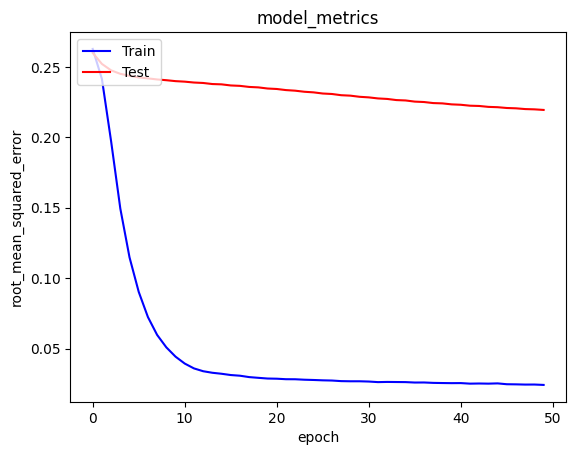

In [ ]:
# plot metrics evaluations
plt.plot(history.history['root_mean_squared_error'], color='blue')
plt.plot(history.history['val_root_mean_squared_error'], color='red')
plt.title('model_metrics')
plt.ylabel('root_mean_squared_error')
plt.xlabel('epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


Visualisasi evaluasi

In [ ]:
# films
films_df = df_film
films_df.head()

,film_id,film_name,genre
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,Adventure|Children|Fantasy
2,3,Grumpier Old Men,Comedy|Romance
3,4,Waiting to Exhale,Comedy|Drama|Romance
4,5,Father of the Bride Part II,Comedy


Siapkan data film

In [ ]:
# data ratings
df = films
df.head()

,movieId,title,genres,year_of_release,userId,rating,timestamp,user,films
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2.0,3.5,2006-03-03 19:57:00,1,0
57309,2,Jumanji,Adventure|Children|Fantasy,1995,9.0,5.0,1997-03-26 13:32:22,8,1
81537,3,Grumpier Old Men,Comedy|Romance,1995,8.0,4.0,1998-03-21 15:08:26,7,2
93341,4,Waiting to Exhale,Comedy|Drama|Romance,1995,141.0,3.0,1996-07-30 07:29:46,119,3
95864,5,Father of the Bride Part II,Comedy,1995,18.0,4.0,2005-02-13 05:52:25,17,4


Gunakan dataframe utama

In [ ]:
# Memilih user aktif (yang telah memberi rating ≥ 50)
user_counts = df.groupby('userId').size()
active_users = user_counts[user_counts >= 50].index.tolist()

# Check if active_users is empty
if not active_users:
    print("No active users found with 50 or more ratings in the filtered dataset.")
    # You might want to exit or handle this case appropriately,
    # depending on how you want to proceed when no such users exist.
    # For demonstration, we'll just print and skip the recommendation logic below.
else:
    # Mengambil satu user aktif secara acak
    user_id = np.random.choice(active_users)

    # Film yang sudah ditonton oleh user tersebut
    films_visited_by_user = df[df['userId'] == user_id]

    # Film yang belum ditonton user
    films_not_visited = films_df.loc[
        ~films_df['film_id'].isin(films_visited_by_user['movieId'].values), 'film_id'
    ]

    # Filter film yang ada dalam encoding
    films_not_visited = list(set(films_not_visited).intersection(set(films_to_films_encoded.keys())))

    # Buat list encoded film yang belum ditonton
    films_not_visited = [[films_to_films_encoded[x]] for x in films_not_visited]

    # Ambil encoded user
    user_encoder = user_to_user_encoded[user_id]

    # Buat array kombinasi user + film
    user_films_array = np.hstack((
        np.full((len(films_not_visited), 1), user_encoder),
        films_not_visited
    ))

    # --- The rest of your recommendation logic would go here, inside this else block ---
    # Prediksi rating film yang belum ditonton user
    ratings = model.predict(user_films_array).flatten()

    # Ambil indeks 10 rating tertinggi secara terbalik (descending)
    top_ratings_indices = np.argsort(ratings)[-10:][::-1]

    # Mapping indeks ke film_id asli
    recommended_films_ids = [films_encoded_to_films[films_not_visited[i][0]] for i in top_ratings_indices]

    print(f"Showing recommendations for users: {user_id}")
    print("===" * 9)
    print("Films with high ratings from user")
    print("----" * 8)

    # Ambil 5 film dengan rating tertinggi yang sudah ditonton user
    top_films_user = films_visited_by_user.sort_values(by='rating', ascending=False).head(5)['movieId'].values

    # Tampilkan nama dan genre film yang sudah ditonton
    for _, row in films_df[films_df['film_id'].isin(top_films_user)].iterrows():
        print(f"{row.film_name} : {row.genre}")

    print("----" * 8)
    print("Top 10 films recommendation")
    print("----" * 8)

    # Tampilkan rekomendasi film berdasarkan prediksi model
    for _, row in films_df[films_df['film_id'].isin(recommended_films_ids)].iterrows():
        print(f"{row.film_name} : {row.genre}")

383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Showing recommendations for users: 187.0
Films with high ratings from user
--------------------------------
MirrorMask : Adventure|Children|Drama|Fantasy
Perfume: The Story of a Murderer : Crime|Drama|Thriller
God Bless America : Comedy|Drama
Ruby Sparks : Comedy|Fantasy|Romance
Sleepwalk with Me : Comedy|Drama
--------------------------------
Top 10 films recommendation
--------------------------------
White Squall : Action|Adventure|Drama
Broken Hearts Club, The : Drama
Lilies : Drama|Fantasy|Romance
Elvira, Mistress of the Dark : Comedy|Horror
Cherish : Comedy|Drama|Thriller
Unvanquished, The : Drama
Collection, The : Action|Horror|Thriller
Death on the Staircase : Crime|Documentary
The ABCs of Death 2 : Comedy|Horror
Terminator Genisys : Action|Adventure|Scifi|Thriller


Ambil satu user & prediksi film

In [ ]:
# Prediksi rating film yang belum ditonton user
ratings = model.predict(user_films_array).flatten()

# Ambil indeks 10 rating tertinggi secara terbalik (descending)
top_ratings_indices = np.argsort(ratings)[-10:][::-1]

# Mapping indeks ke film_id asli
recommended_films_ids = [films_encoded_to_films[films_not_visited[i][0]] for i in top_ratings_indices]

print(f"Showing recommendations for users: {user_id}")
print("===" * 9)
print("Films with high ratings from user")
print("----" * 8)

# Ambil 5 film dengan rating tertinggi yang sudah ditonton user
top_films_user = films_visited_by_user.sort_values(by='rating', ascending=False).head(5)['movieId'].values

# Tampilkan nama dan genre film yang sudah ditonton
for _, row in films_df[films_df['film_id'].isin(top_films_user)].iterrows():
    print(f"{row.film_name} : {row.genre}")

print("----" * 8)
print("Top 10 films recommendation")
print("----" * 8)

# Tampilkan rekomendasi film berdasarkan prediksi model
for _, row in films_df[films_df['film_id'].isin(recommended_films_ids)].iterrows():
    print(f"{row.film_name} : {row.genre}")

383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Showing recommendations for users: 187.0
Films with high ratings from user
--------------------------------
MirrorMask : Adventure|Children|Drama|Fantasy
Perfume: The Story of a Murderer : Crime|Drama|Thriller
God Bless America : Comedy|Drama
Ruby Sparks : Comedy|Fantasy|Romance
Sleepwalk with Me : Comedy|Drama
--------------------------------
Top 10 films recommendation
--------------------------------
White Squall : Action|Adventure|Drama
Broken Hearts Club, The : Drama
Lilies : Drama|Fantasy|Romance
Elvira, Mistress of the Dark : Comedy|Horror
Cherish : Comedy|Drama|Thriller
Unvanquished, The : Drama
Collection, The : Action|Horror|Thriller
Death on the Staircase : Crime|Documentary
The ABCs of Death 2 : Comedy|Horror
Terminator Genisys : Action|Adventure|Scifi|Thriller


Prediksi dan tampilkan rekomendasi

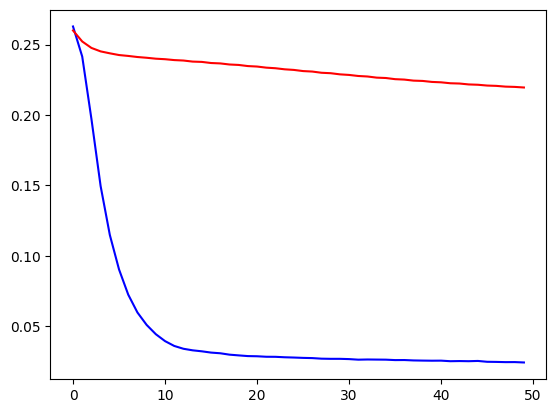

In [ ]:
plt.plot(history.history['root_mean_squared_error'], color='blue')
plt.plot(history.history['val_root_mean_squared_error'], color='red')

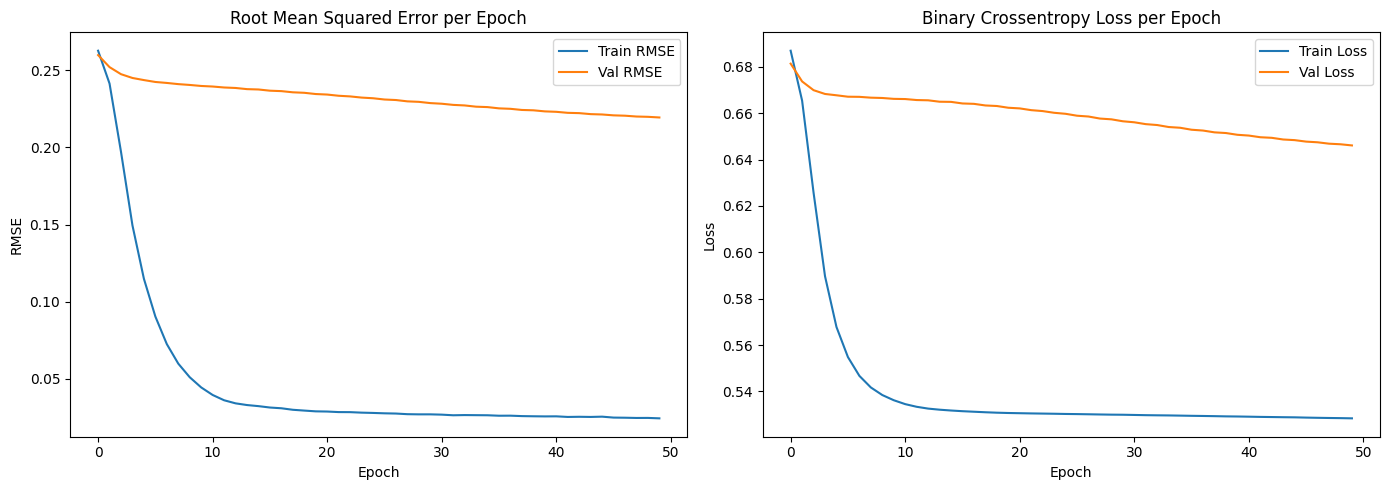

In [ ]:
# Plot RMSE dan Loss selama pelatihan
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
ax[0].plot(history.history['root_mean_squared_error'], label='Train RMSE')
ax[0].plot(history.history['val_root_mean_squared_error'], label='Val RMSE')
ax[0].set_title('Root Mean Squared Error per Epoch')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('RMSE')
ax[0].legend()

# Loss
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Binary Crossentropy Loss per Epoch')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()


Visualisasi RMSE dan Loss

In [ ]:
def precision_at_k(recommended_ids, user_id, k=10):
    # Ambil semua film yang disukai user (rating >= 4)
    liked_by_user = df[(df['userId'] == user_id) & (df['rating'] >= 4)]['movieId'].values

    # Hitung berapa dari top-k rekomendasi yang termasuk dalam daftar liked_by_user
    hits = [film for film in recommended_ids[:k] if film in liked_by_user]
    precision = len(hits) / k

    print(f"Precision@{k}: {precision:.2f}")
    return precision


In [ ]:
precision_at_k(recommended_films_ids, user_id, k=10)

Precision@10: 0.00


0.0

Evaluasi Precision@k

# collaborative filtering

In [ ]:
class RecommenderNet(tf.keras.Model):
    def __init__(self, num_users, num_items, embedding_size):
        super().__init__()
        self.user_embedding = layers.Embedding(num_users, embedding_size)
        self.item_embedding = layers.Embedding(num_items, embedding_size)
        self.user_bias = layers.Embedding(num_users, 1)
        self.item_bias = layers.Embedding(num_items, 1)

    def call(self, inputs):
        user_vec = self.user_embedding(inputs[:, 0])
        item_vec = self.item_embedding(inputs[:, 1])
        dot = tf.reduce_sum(user_vec * item_vec, axis=1, keepdims=True)
        return tf.nn.sigmoid(dot + self.user_bias(inputs[:, 0]) + self.item_bias(inputs[:, 1]))


Arsitektur Model


In [ ]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(x_val, y_val)
)

Epoch 1/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.5304 - root_mean_squared_error: 0.0385 - val_loss: 0.6436 - val_root_mean_squared_error: 0.2185
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.5305 - root_mean_squared_error: 0.0372 - val_loss: 0.6436 - val_root_mean_squared_error: 0.2183
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.5317 - root_mean_squared_error: 0.0314 - val_loss: 0.6435 - val_root_mean_squared_error: 0.2178
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.5327 - root_mean_squared_error: 0.0305 - val_loss: 0.6435 - val_root_mean_squared_error: 0.2178
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.5305 - root_mean_squared_error: 0.0287 - val_loss: 0.6432 - val_root_mean_squared_error: 0.2174
Epoch 6/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.5282 - root_mean_squared_error: 0.0271 - val_loss: 0.6432 - val_root_mean_squared_error: 0.2174
Epoch 7/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/s

Pelatihan Model

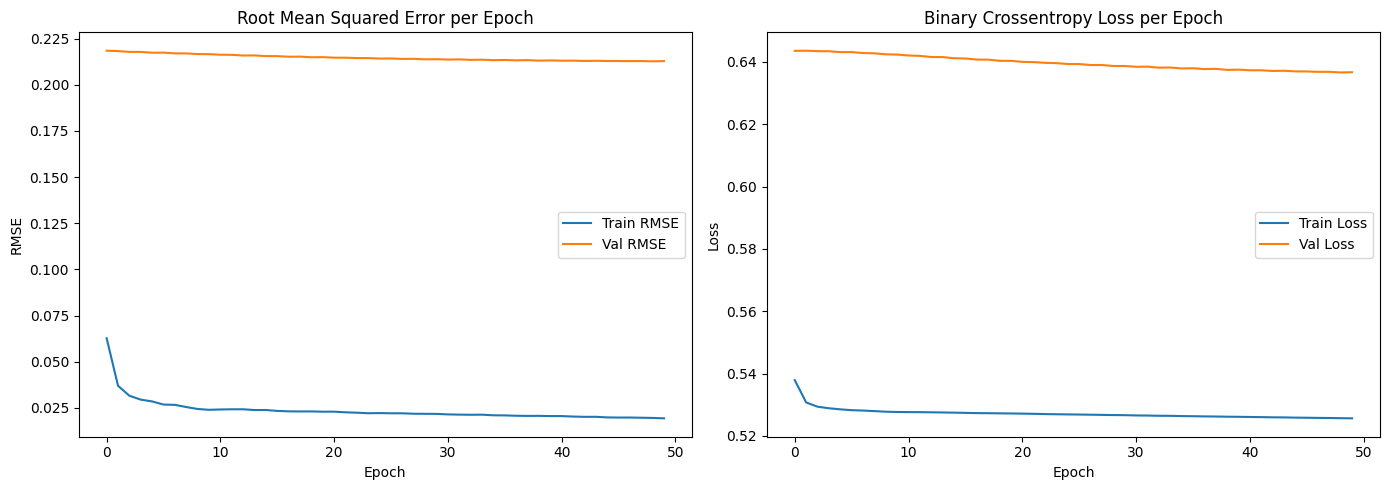

In [ ]:
# Plot RMSE dan Loss selama pelatihan
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
ax[0].plot(history.history['root_mean_squared_error'], label='Train RMSE')
ax[0].plot(history.history['val_root_mean_squared_error'], label='Val RMSE')
ax[0].set_title('Root Mean Squared Error per Epoch')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('RMSE')
ax[0].legend()

# Loss
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Binary Crossentropy Loss per Epoch')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

Visualisasi RMSE dan Loss

In [ ]:
# Pilih user aktif
user_counts = df.groupby('userId').size()
active_users = user_counts[user_counts >= 50].index.tolist()
user_id = np.random.choice(active_users)

# Film yang sudah ditonton oleh user tersebut
films_visited_by_user = df[df['userId'] == user_id]

# Film yang belum ditonton user
films_not_visited = films_df.loc[
    ~films_df['film_id'].isin(films_visited_by_user['movieId'].values), 'film_id'
]

films_not_visited = list(set(films_not_visited).intersection(set(films_to_films_encoded.keys())))
films_not_visited = [[films_to_films_encoded[x]] for x in films_not_visited]

user_encoder = user_to_user_encoded[user_id]
user_films_array = np.hstack((
    np.full((len(films_not_visited), 1), user_encoder),
    films_not_visited
))

 Pilih User Aktif dan Prediksi

In [ ]:
ratings = model.predict(user_films_array).flatten()
top_ratings_indices = np.argsort(ratings)[-10:][::-1]
recommended_films_ids = [films_encoded_to_films[films_not_visited[i][0]] for i in top_ratings_indices]

print(f"Rekomendasi untuk user {user_id}")
print("===" * 10)

print("5 Film yang disukai user:")
top_films_user = films_visited_by_user.sort_values(by='rating', ascending=False).head(5)['movieId'].values
for _, row in films_df[films_df['film_id'].isin(top_films_user)].iterrows():
    print(f"{row.film_name} : {row.genre}")

print("===" * 10)
print("10 Rekomendasi Teratas:")
for _, row in films_df[films_df['film_id'].isin(recommended_films_ids)].iterrows():
    print(f"{row.film_name} : {row.genre}")

392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Rekomendasi untuk user 80.0
5 Film yang disukai user:
Fan, The : Drama|Thriller
Desperate Measures : Crime|Drama|Thriller
187 : Drama|Thriller
U Turn : Crime|Drama|Mystery
Way of the Gun, The : Crime|Thriller
10 Rekomendasi Teratas:
The Journey of August King : Drama
Boys Life : Drama
Careful : Comedy|Horror
Truth or Consequences, N.M. : Action|Crime|Romance
Man and a Woman, A : Drama|Romance
Phish: Bittersweet Motel : Documentary
Tree Grows in Brooklyn, A : Drama
I Remember Mama : Children|Drama
Room 237 : Documentary
Scenic Route : Drama|Thriller


Prediksi & Cetak Hasil Rekomendasi

In [ ]:
def precision_at_k(recommended_ids, user_id, k=10):
    liked_by_user = df[(df['userId'] == user_id) & (df['rating'] >= 4)]['movieId'].values
    hits = [film for film in recommended_ids[:k] if film in liked_by_user]
    precision = len(hits) / k
    print(f"Precision@{k}: {precision:.2f}")
    return precision

In [ ]:
precision_at_k(recommended_films_ids, user_id, k=10)

Precision@10: 0.00


0.0

Precision@10